# Week 9 – Day 1 Lab
## Stable Diffusion: Text-to-Image Generation

### Objectives

By the end of this lab, you will:
- Generate images using Stable Diffusion.
- Understand how prompts influence image generation.
- Experiment with inference steps, CFG scale, and random seeds.
- Build a mini AI-generated image gallery.


# Step 1: Enable GPU Runtime

Stable Diffusion requires significant computational power to generate images efficiently. Google Colab provides free access to GPUs, which can greatly speed up image generation.

Before proceeding, switch your notebook to use a GPU.

### Instructions

1. Click **Runtime** in the top menu.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, choose **T4 GPU** (or any available GPU).
4. Click **Save**.

### Verify that the GPU is Available

Run the code cell below to check whether your notebook is connected to a GPU. If the GPU is available, the output should display the name of the GPU (e.g., NVIDIA Tesla T4).

In [1]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available!")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU is not available. Please enable GPU from Runtime → Change runtime type.")

✅ GPU is available!
GPU Name: Tesla T4


# Step 2: Install Required Libraries

Stable Diffusion is not included in Google Colab by default, so we first need to install the required Python libraries.

The following packages will be installed:

- **diffusers** – Provides Stable Diffusion models.
- **transformers** – Used for text encoding.
- **accelerate** – Optimizes model execution.
- **safetensors** – Secure model loading.

Run the following cell to install these packages.

In [2]:
!pip install -q diffusers transformers accelerate safetensors

# Step 3: Import Required Libraries

Now that the required packages are installed, we need to import them into our notebook.

We will use:

- **torch** for tensor computations.
- **StableDiffusionPipeline** to load the pre-trained model.
- **matplotlib** to display generated images.

Run the following cell.

In [3]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


#Load the Stable Diffusion Model

Stable Diffusion is a pre-trained generative AI model capable of converting text descriptions into images.

In this step, we will load the model and prepare it for image generation.

**Note:** The first execution may take several minutes because the model needs to be downloaded.


Hints:

- Use StableDiffusionPipeline.from_pretrained()
- The model name is:
  runwayml/stable-diffusion-v1-5
- Move the pipeline to the GPU.

In [20]:
#write your code here
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

# Generate Your First AI Image

Let's generate your first AI image!



Complete the code below to generate an image for the following prompt:

> "A futuristic city at sunset"

Display the generated image.

  0%|          | 0/50 [00:00<?, ?it/s]

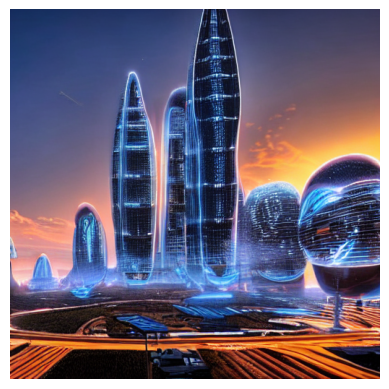

In [21]:
#write your code here
prompt = "A futuristic city at sunset"

image = pipe(prompt).images[0]

plt.imshow(image)
plt.axis("off")
plt.show()

# Experiment 1: Prompt Engineering

The quality of an AI-generated image depends greatly on the prompt.

Generate images using both prompts below.

### Prompt 1

Dog

### Prompt 2

A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography



generate both images.

  0%|          | 0/50 [00:00<?, ?it/s]

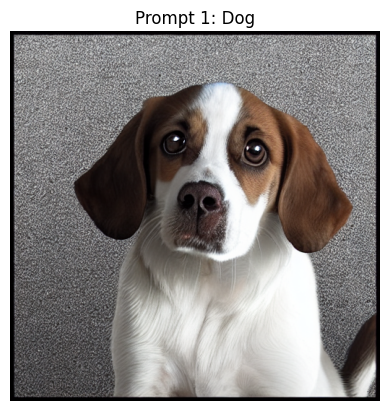

In [22]:
#write code here
prompt1 = "Dog"

image1 = pipe(prompt1).images[0]

plt.imshow(image1)
plt.axis("off")
plt.title("Prompt 1: Dog")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

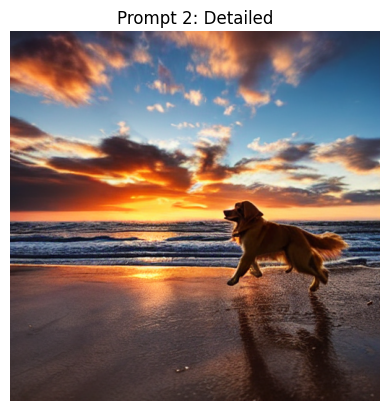

In [27]:
#write code here
prompt2 = "A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography"

image2 = pipe(prompt2).images[0]

plt.imshow(image2)
plt.axis("off")
plt.title("Prompt 2: Detailed")
plt.show()

## Reflection

1. Which prompt generated the better image?

2. Which image contained more details?

3. Why do detailed prompts usually produce better results?

In [ ]:
#answer here

**Which prompt generated the better image?**
Prompt 2

**Which image contained more details?**
Prompt 2

**Why do detailed prompts usually produce better results?**
A vague prompt like "Dog" leaves the model with very little to constrain its output — it has to guess breed, pose, setting, lighting, and style essentially at random. A detailed prompt gives the model explicit signals for subject, action, environment, lighting, and artistic style, narrowing down the space of possible images and steering generation toward something coherent and closer to what you actually envisioned.

# Experiment 2: Inference Steps

Stable Diffusion gradually removes noise over multiple iterations.

These iterations are called **Inference Steps**.


Generate the same image using:

- 20 inference steps
- 50 inference steps

  0%|          | 0/20 [00:00<?, ?it/s]

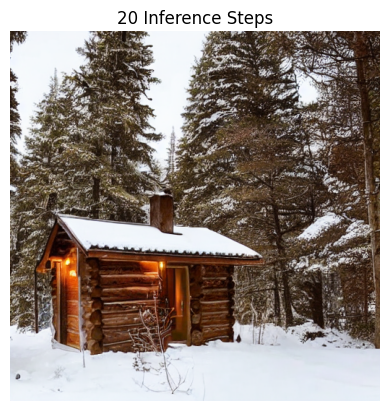

In [30]:
#write your code here
prompt = "A cozy cabin in a snowy forest, warm lights glowing from the windows"

image_20 = pipe(prompt, num_inference_steps=20).images[0]

plt.imshow(image_20)
plt.axis("off")
plt.title("20 Inference Steps")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

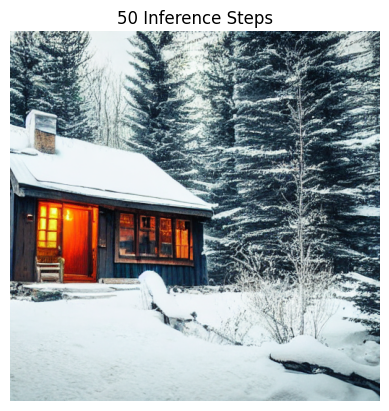

In [31]:
#write your code here
image_50 = pipe(prompt, num_inference_steps=50).images[0]

plt.imshow(image_50)
plt.axis("off")
plt.title("50 Inference Steps")
plt.show()

## Reflection

- Which image looks sharper?

- Was there a noticeable improvement?

- Did image generation take longer?

In [11]:
#answer here

**Which image looks sharper?**
The 50-step image looks sharper and more refined than the 20-step one.

**Was there a noticeable improvement?**
Yes, quite noticeable here. Beyond sharpness, the 50-step image has richer, warmer window lighting (the orange glow looks more saturated and realistic) and better-defined contrast between the dark trees and white snow. The 20-step version looks a bit flatter and more washed out overall.

**Did image generation take longer?**
Yes

# Experiment 3: Guidance Scale (CFG)

CFG controls how closely Stable Diffusion follows your prompt.


Generate the same prompt using:

- CFG = 5
- CFG = 8
- CFG = 12



  0%|          | 0/50 [00:00<?, ?it/s]

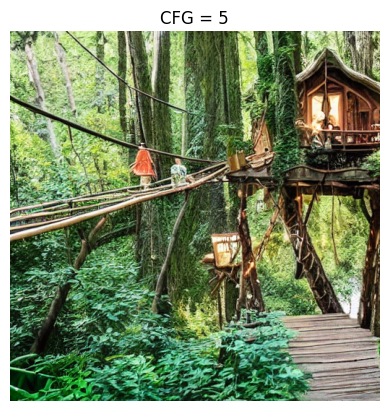

In [32]:
#write code here
prompt = "A magical treehouse village connected by rope bridges in an enchanted forest"

image_cfg5 = pipe(prompt, guidance_scale=5).images[0]
plt.imshow(image_cfg5)
plt.axis("off")
plt.title("CFG = 5")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

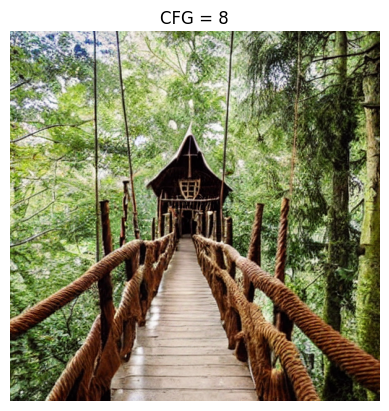

In [33]:
#write code here
image_cfg8 = pipe(prompt, guidance_scale=8).images[0]
plt.imshow(image_cfg8)
plt.axis("off")
plt.title("CFG = 8")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

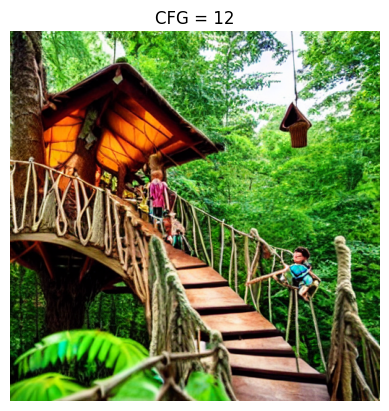

In [34]:
#write code here
image_cfg12 = pipe(prompt, guidance_scale=12).images[0]
plt.imshow(image_cfg12)
plt.axis("off")
plt.title("CFG = 12")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

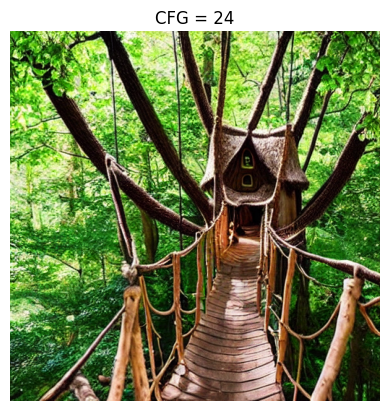

In [35]:
#write code here
image_cfg12 = pipe(prompt, guidance_scale=12).images[0]
plt.imshow(image_cfg24)
plt.axis("off")
plt.title("CFG = 24")
plt.show()

## Reflection

- Which CFG value produced the best image?

- Which image followed the prompt most accurately?

- What happens when CFG becomes too high?

In [15]:
#answer here

**Which CFG value produced the best image?**
CFG = 12 produced the best overall image
it clearly shows a full treehouse village with people crossing rope bridges, warm interior lighting, and rich forest detail, all rendered with strong composition and clarity.

**Which image followed the prompt most accurately?**
CFG = 12 followed the prompt most accurately and completely, capturing both the "treehouse" and "rope bridge" elements together in one coherent scene with figures actively using the bridge.

**What happens when CFG becomes too high?**
At CFG = 24, the image starts to look too perfect and repeated
the rope bridge and branches look almost the same on both sides, like a mirror image. The colors are also more intense and the tree branches look a bit fake, more like a drawing than a real photo.

# Experiment 4: Random Seed

Every image starts from random noise.

Changing the seed changes the starting noise, resulting in different images.



Complete the code below.

Generate images using the following seeds:

- 42
- 100
- 500



  0%|          | 0/50 [00:00<?, ?it/s]

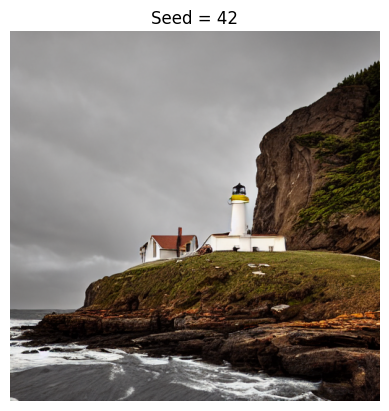

In [36]:
#write code here
prompt = "An old lighthouse on a rocky cliff during a storm"

generator = torch.Generator("cuda").manual_seed(42)
image_seed42 = pipe(prompt, generator=generator).images[0]

plt.imshow(image_seed42)
plt.axis("off")
plt.title("Seed = 42")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

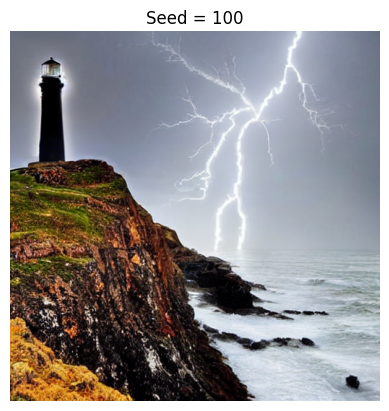

In [37]:
#write code here
generator = torch.Generator("cuda").manual_seed(100)
image_seed100 = pipe(prompt, generator=generator).images[0]

plt.imshow(image_seed100)
plt.axis("off")
plt.title("Seed = 100")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

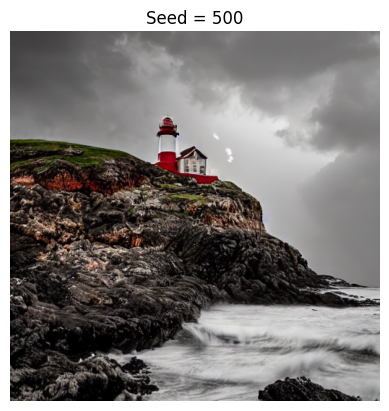

In [38]:
#write code here
generator = torch.Generator("cuda").manual_seed(500)
image_seed500 = pipe(prompt, generator=generator).images[0]

plt.imshow(image_seed500)
plt.axis("off")
plt.title("Seed = 500")
plt.show()

## Reflection

- Which seed generated your favorite image?

- What changed when the seed changed?

- Why are seeds useful when reproducing results?

In [19]:
#answer here

**Which seed generated your favorite image?**
Seed = 500 generated the favorite image
it had the most dramatic and well-composed storm scene, with the lighthouse strongly lit against dark, turbulent clouds and crashing waves, giving it the most cinematic feel of the three.

**What changed when the seed changed?**
Each seed produced a completely different composition even though the prompt stayed the same
the position and shape of the lighthouse, the angle of the cliff, the intensity of the storm clouds, and the wave patterns all varied.

**Why are seeds useful when reproducing results?**
Seeds fix the initial random noise that the diffusion process starts from. Without a fixed seed, every run produces a different image even with an identical prompt, making it impossible to recreate a specific result. By setting a seed, you can reproduce the exact same image later, share reproducible results with others, or systematically test how other parameters (like CFG or steps) affect the image while keeping the starting point constant.